# Data Understanding

This notebook examines the structure, quality, target distribution, and temporal characteristics of the 2020-2023 development dataset.

The 2024 data is reserved as a final holdout set and is not inspected during data understanding, feature analysis, feature engineering, or model selection.

## Setup

### Imports


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data import load_development_data

## Load Data

In [2]:
train_df = load_development_data()

In [3]:
train_df.head()

,pk_teuna_fikt,sug_tik,THUM_GEOGRAFI,SUG_DEREH,SEMEL_YISHUV,REHOV1,REHOV2,BAYIT,ZOMET_IRONI,KVISH1,...,KIVUN_HAZIYA,MAHOZ,NAFA,EZOR_TIVI,MAAMAD_MINIZIPALI,ZURAT_ISHUV,STATUS_IGUN,X,Y,file
0,2020000003,1,1,3,0,NaN,NaN,NaN,NaN,461.0,...,9,5,51,512,99.0,99.0,1,185093.0,660450.0,h20201332
1,2020000009,1,1,1,6500,602.0,609.0,NaN,210007.0,NaN,...,1,3,32,324,0.0,14.0,1,192948.0,704662.0,h20201332
2,2020000014,1,1,1,8300,970.0,NaN,NaN,NaN,NaN,...,9,4,44,442,0.0,13.0,3,175302.0,655930.0,h20201332
3,2020000035,1,1,1,7900,424.0,304.0,NaN,9850054.0,NaN,...,9,4,42,422,0.0,13.0,1,190940.0,665512.0,h20201332
4,2020000043,1,1,2,8400,363.0,NaN,80.0,NaN,NaN,...,1,4,44,441,0.0,14.0,1,181573.0,644722.0,h20201332


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41626 entries, 0 to 41625
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pk_teuna_fikt      41626 non-null  int64  
 1   sug_tik            41626 non-null  int64  
 2   THUM_GEOGRAFI      41626 non-null  int64  
 3   SUG_DEREH          41626 non-null  int64  
 4   SEMEL_YISHUV       41626 non-null  int64  
 5   REHOV1             26060 non-null  float64
 6   REHOV2             13080 non-null  float64
 7   BAYIT              14544 non-null  float64
 8   ZOMET_IRONI        13080 non-null  float64
 9   KVISH1             13551 non-null  float64
 10  KVISH2             13350 non-null  float64
 11  KM                 13527 non-null  float64
 12  ZOMET_LO_IRONI     5281 non-null   float64
 13  YEHIDA             41626 non-null  int64  
 14  SHNAT_TEUNA        41626 non-null  int64  
 15  HODESH_TEUNA       41626 non-null  int64  
 16  SHAA               41626 non-null

## Data Dictionary

Based on the local codebook files and [Codebook](https://www.cbs.gov.il/he/publications/DocLib1/2015/PUF/%D7%AA%D7%97%D7%91%D7%95%D7%A8%D7%94/H20131162AccCodebook.pdf)



| Field | Meaning | Notes |
|---|---|---|
| `PK_TEUNA_FIKT` | Synthetic accident identifier | |
| `SUG_TIK` | Accident file type | Describes police-investigated road accidents with casualties |
| `THUM_GEOGRAFI` | Geographic area | Israel excluding Judea and Samaria, or Judea and Samaria |
| `SUG_DEREH` | Road type | Combines urban/non-urban and intersection/non-intersection |
| `SEMEL_YISHUV` | Locality code | Referenced against the official locality list |
| `REHOV1` | Primary street code | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `REHOV2` | Secondary street code | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `BAYIT` | House number | Named `MISPAR_BAIT` in the codebook. Available only for urban roads not at an intersection (`SUG_DEREH = 2`) |
| `ZOMET_IRONI` | Urban intersection code | Available only for urban intersections (`SUG_DEREH = 1`) |
| `KVISH1` | Primary non-urban road number | Available only for non-urban roads (`SUG_DEREH` 3 or 4) |
| `KVISH2` | Secondary non-urban road number | Available only for non-urban roads (`SUG_DEREH` 3 or 4) |
| `KM` | Kilometer marker | For non-urban locations. When the hundreds-of-meters value is unknown, it is marked accordingly in the source data |
| `ZOMET_LO_IRONI` | Non-urban intersection code | Available only for non-urban intersections (`SUG_DEREH = 3`) |
| `YEHIDA` | Police unit | |
| `SHNAT_TEUNA` | Accident year | |
| `HODESH_TEUNA` | Accident month | |
| `SHAA` | Accident hour | |
| `SUG_YOM` | Day type | Computed from the Hebrew calendar and classified as holiday, holiday eve, intermediate festival day, or other day |
| `YOM_LAYLA` | Day / night | Computed according to daylight and darkness hours for that date |
| `YOM_BASHAVUA` | Day of week | |
| `HUMRAT_TEUNA` | Accident severity | Target field: Fatal, Serious, or Slight |
| `SUG_TEUNA` | Accident type | |
| `HAD_MASLUL` | Single-carriageway configuration | Alternative to `RAV_MASLUL`. When this field contains the applicable configuration, `RAV_MASLUL` is set to `0` |
| `RAV_MASLUL` | Multi-carriageway / median configuration | Alternative to `HAD_MASLUL`. When this field contains the applicable configuration, `HAD_MASLUL` is set to `0` |
| `MEHIRUT_MUTERET` | Permitted speed | `0` means Unknown |
| `TKINUT` | Road condition | `0` means Unknown |
| `ROHAV` | Road width | `0` means Unknown |
| `SIMUN_TIMRUR` | Road markings / traffic signs condition | |
| `TEURA` | Lighting conditions | Includes explicit unknown day/night categories |
| `MEZEG_AVIR` | Weather conditions | |
| `PNE_KVISH` | Road surface condition | |
| `SUG_EZEM` | Type of stationary object struck | Based on the codebook, applicable only when `SUG_TEUNA = 8` (collision with stationary object) |
| `MERHAK_EZEM` | Distance of stationary object from road | Based on the codebook, applicable only when `SUG_TEUNA = 8` |
| `LO_HAZA` | Pedestrian activity when not crossing | Applicable only when `SUG_TEUNA = 1`. Alternative to `OFEN_HAZIYA` |
| `OFEN_HAZIYA` | Pedestrian crossing behavior | Applicable only when `SUG_TEUNA = 1`. Alternative to `LO_HAZA` |
| `MEKOM_HAZIYA` | Pedestrian crossing location | Applicable only when `SUG_TEUNA = 1` |
| `KIVUN_HAZIYA` | Pedestrian crossing direction | Applicable only when `SUG_TEUNA = 1` |
| `MAHOZ` | District | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `NAFA` | Subdistrict | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `EZOR_TIVI` | Natural region | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `MAAMAD_MINIZIPALI` | Municipal status | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `ZURAT_ISHUV` | Locality type | Available only for urban roads (`SUG_DEREH` 1 or 2) |
| `STATUS_IGUN` | Geocoding quality | Named `IGUN_MEKUBAZ` in the codebook |
| `X` | X coordinate | Named `X_KORDINAT` in the codebook |
| `Y` | Y coordinate | Named `Y_KORDINAT` in the codebook |
| `file` | Source file | Identifies the yearly source file in the combined dataset; not a field described in the CBS codebook |

### Value Mappings

In [5]:
from src.codebook import VALUE_LABELS

## Temporal Train-Test Strategy
A temporal split is used to reflect the intended prediction setting. Data from 2020-2023 is used for development, while 2024 is reserved as a final holdout test set. Model selection and feature evaluation are performed using temporal cross-validation within the development period.

A separate static validation set is not created. Instead, model selection will use expanding-window temporal cross-validation within the 2020-2023 development data.

In [6]:
print("Development shape:", train_df.shape)
print(
    "Development years:",
    sorted(train_df["SHNAT_TEUNA"].unique())
)

assert set(train_df["SHNAT_TEUNA"].unique()) == {
    2020, 2021, 2022, 2023
}

Development shape: (41626, 46)
Development years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [7]:
yearly_target_distribution = (
    pd.crosstab(
        train_df["SHNAT_TEUNA"],
        train_df["HUMRAT_TEUNA"],
        normalize="index"
    )
    .mul(100)
    .rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])
)

yearly_target_distribution.round(2)

HUMRAT_TEUNA,Fatal,Serious,Slight
SHNAT_TEUNA,,,
2020,2.64,17.52,79.84
2021,2.91,19.11,77.98
2022,3.07,22.30,74.63
2023,3.83,26.88,69.29


In [8]:
pd.crosstab(
    train_df["SHNAT_TEUNA"],
    train_df["HUMRAT_TEUNA"]
).rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])

HUMRAT_TEUNA,Fatal,Serious,Slight
SHNAT_TEUNA,,,
2020,286,1899,8651
2021,336,2208,9010
2022,319,2320,7765
2023,338,2374,6120


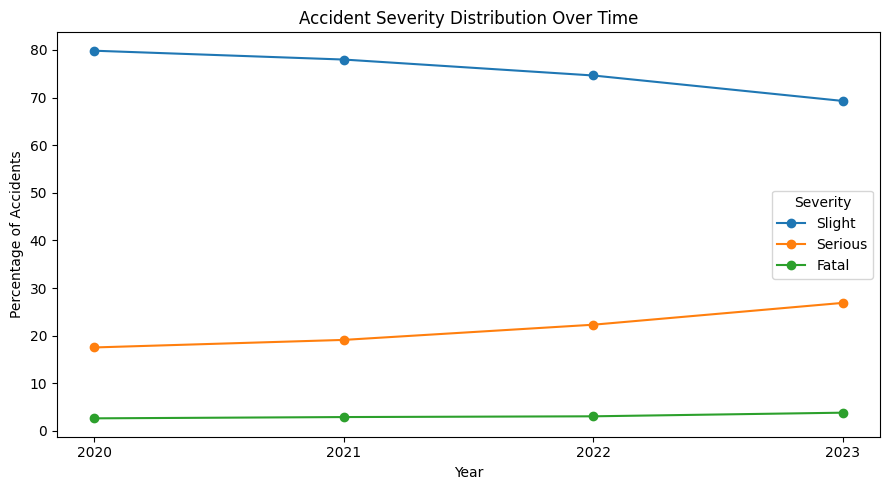

In [9]:
yearly_target_distribution = (
    pd.crosstab(
        train_df["SHNAT_TEUNA"],
        train_df["HUMRAT_TEUNA"],
        normalize="index"
    )
    .mul(100)
    .rename(columns=VALUE_LABELS["HUMRAT_TEUNA"])
)

yearly_target_distribution[
    ["Slight", "Serious", "Fatal"]
].plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

plt.title("Accident Severity Distribution Over Time")
plt.xlabel("Year")
plt.ylabel("Percentage of Accidents")
plt.xticks(yearly_target_distribution.index)
plt.legend(title="Severity")

plt.tight_layout()
plt.show()

### Split Observations

The 2024 data is reserved as a final holdout test set and remains sealed during exploratory analysis, feature engineering, and model selection.

Only the partition sizes and covered years are verified at this stage.

All feature analysis, preprocessing decisions, feature selection, and model tuning are performed using the 2020-2023 development data.

The 2024 target distribution and feature behavior will be examined only after the modeling pipeline has been finalized.

## Data Overview

In [10]:
rows = []
for col in train_df.columns:
    non_null = train_df[col].dropna()

    sample_values = (
        non_null.astype(str)
        .drop_duplicates()
        .head(5)
        .tolist()
    )

    rows.append({
        "column": col,
        "dtype": str(train_df[col].dtype),
        "unique": train_df[col].nunique(dropna=True),
        "missing_count": train_df[col].isna().sum(),
        "missing_%": round(train_df[col].isna().mean() * 100, 2),
        "sample_values": sample_values,
    })

statistics = pd.DataFrame(rows)
statistics


,column,dtype,unique,missing_count,missing_%,sample_values
0,pk_teuna_fikt,int64,41626,0,0.00,"[2020000003, 2020000009, 2020000014, 202000003..."
1,sug_tik,int64,1,0,0.00,[1]
2,THUM_GEOGRAFI,int64,2,0,0.00,"[1, 2]"
3,SUG_DEREH,int64,4,0,0.00,"[3, 1, 2, 4]"
4,SEMEL_YISHUV,int64,555,0,0.00,"[0, 6500, 8300, 7900, 8400]"
5,REHOV1,float64,2052,15566,37.39,"[602.0, 970.0, 424.0, 363.0, 1135.0]"
6,REHOV2,float64,1749,28546,68.58,"[609.0, 304.0, 905.0, 426.0, 2465.0]"
7,BAYIT,float64,266,27082,65.06,"[80.0, 140.0, 9999.0, 2.0, 90.0]"
8,ZOMET_IRONI,float64,5177,28546,68.58,"[210007.0, 9850054.0, 30051.0, 80230093.0, 149..."
9,KVISH1,float64,524,28075,67.45,"[461.0, 444.0, 85.0, 5803.0, 3875.0]"
